<h2 style="font-weight:bold;">SYNTHETIC HEALTH DATA</h2>

<h2 style="font-weight:bold;">1.INTRODUCTION</h2>


Data cleaning is the process of preparing raw data for machine learning by fixing errors, handling missing values, removing duplicates, and standardizing formats. Since model performance depends on data quality, clean and consistent data is essential for accurate and reliable predictions.

The dataset contains health-related data for 1000 individuals,including features like age,bmi,excercise frequancy,diet quality, sleep hours,smoking status and alcohol consumption.The target variables is health score.
It is used to analyse the relationship between lifestyle factors and health,supporting correlation analysis, feature selection and regression modeling 

<h2 style="font-weight:bold;">2. IMPORTING REQUIRED LIBRARIES</h2>

<p style="font-size:16px;">
In this step, all the necessary libraries required for data analysis, visualization, and machine learning are imported. 
These libraries provide tools for handling data, creating visualizations, and building predictive models.
</p>

<ul style="font-size:16px;">
  <li>NumPy is used for numerical operations and handling arrays</li>
  <li>Pandas is used for data manipulation and analysis</li>
  <li>Matplotlib and Seaborn are used for data visualization</li>
  <li>Scikit-learn (sklearn) is used for machine learning models and evaluation</li>
  <li>Metrics from sklearn are used to evaluate model performance</li>
</ul>

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

<h2 style="font-weight:bold;">7. LOAD THE DATA</h2>

<p style="font-size:16px;">
In this step, the dataset is loaded into the environment for further analysis and processing. 
The data is typically imported using libraries like Pandas, which allows easy handling of structured data.
</p>

<ul style="font-size:16px;">
  <li>Dataset is loaded using Pandas (read_csv or similar functions)</li>
  <li>Initial inspection is done using head(), tail(), and info()</li>
  <li>Shape of the dataset is checked to understand rows and columns</li>
  <li>Data types of each feature are examined</li>
  <li>Basic statistics are reviewed using describe()</li>
</ul>

In [143]:
df=pd.read_csv(r"C:\data science\work space\synthetic_health_data.csv")
print(df)

           Age        BMI  Exercise_Frequency  Diet_Quality  Sleep_Hours  \
0    45.960570  31.996777                   5     55.403270     7.300359   
1    38.340828  29.623168                   6     41.838357     7.012419   
2    47.772262  25.298152                   5     76.904948     6.028641   
3    58.276358  21.765316                   2     49.756767     5.802714   
4    37.190160  28.491117                   2     44.218737     7.912548   
..         ...        ...                 ...           ...          ...   
995  36.626796  30.350751                   1     60.674477     8.470913   
996  61.572238  24.867394                   3     66.527725     5.355398   
997  47.690114  20.590627                   4     69.819819     8.641864   
998  33.145852  24.184665                   6     70.724204     7.941557   
999  46.870993  21.275487                   0     63.555888     9.038352   

     Smoking_Status  Alcohol_Consumption  Health_Score  
0                 0           

<h2 style="font-weight:bold;">3. DATA UNDERSTANDING</h2>

<p style="font-size:16px;">
In this step, the dataset is explored to understand its structure, features, and overall characteristics. 
This helps in identifying the type of data, detecting missing values, and gaining initial insights before performing detailed analysis.
</p>

<ul style="font-size:16px;">
  <li>View first and last few records using head() and tail()</li>
  <li>Check dataset structure using info()</li>
  <li>Identify data types of each feature</li>
  <li>Check for missing or null values</li>
  <li>Understand statistical summary using describe()</li>
  <li>Analyze target variable distribution</li>
</ul>

In [144]:
target_corr=df.corr()['Health_Score'].sort_values(ascending=False)
print(target_corr)

Health_Score           1.000000
Diet_Quality           0.680686
Sleep_Hours            0.269033
Exercise_Frequency     0.245036
Smoking_Status        -0.109123
Alcohol_Consumption   -0.138264
Age                   -0.186939
BMI                   -0.415147
Name: Health_Score, dtype: float64


In [145]:
print(df.head(10))

         Age        BMI  Exercise_Frequency  Diet_Quality  Sleep_Hours  \
0  45.960570  31.996777                   5     55.403270     7.300359   
1  38.340828  29.623168                   6     41.838357     7.012419   
2  47.772262  25.298152                   5     76.904948     6.028641   
3  58.276358  21.765316                   2     49.756767     5.802714   
4  37.190160  28.491117                   2     44.218737     7.912548   
5  37.190357  26.967427                   2     89.124837     7.786489   
6  58.950554  29.475966                   5     81.522693     7.085705   
7  49.209217  28.175859                   3     65.002425     8.386293   
8  34.366307  30.247764                   4     67.989301     4.058009   
9  46.510721  22.323824                   4     33.889837     6.153408   

   Smoking_Status  Alcohol_Consumption  Health_Score  
0               0             2.834707     70.542122  
1               1             7.199517     57.244637  
2               1   

In [146]:
print(df.describe())

               Age          BMI  Exercise_Frequency  Diet_Quality  \
count  1000.000000  1000.000000         1000.000000   1000.000000   
mean     40.231985    25.354181            2.888000     69.952977   
std      11.750591     4.987272            1.995354     14.972061   
min       1.104792    10.298057            0.000000     19.907497   
25%      32.228916    21.968792            1.000000     59.945481   
50%      40.303607    25.315386            3.000000     69.975151   
75%      47.775327    28.644411            5.000000     80.527839   
max      86.232778    40.965538            6.000000    110.265186   

       Sleep_Hours  Smoking_Status  Alcohol_Consumption  Health_Score  
count  1000.000000     1000.000000          1000.000000   1000.000000  
mean      6.973135        0.499000             3.079377     85.479947  
std       1.517218        0.500249             2.084564     13.633845  
min       2.431107        0.000000            -3.592506     29.106017  
25%       5.903351

In [147]:
print(df.dtypes)

Age                    float64
BMI                    float64
Exercise_Frequency       int64
Diet_Quality           float64
Sleep_Hours            float64
Smoking_Status           int64
Alcohol_Consumption    float64
Health_Score           float64
dtype: object


In [148]:
print(df.empty)

False


In [149]:
print(df.size)

8000


In [150]:
print(df.shape)

(1000, 8)


<h2 style="font-weight:bold;">4. DATA CLEANING</h2>

<p style="font-size:16px;">
In this step, the dataset is cleaned to ensure accuracy and consistency. 
Data cleaning involves handling missing values, removing duplicates, and correcting any inconsistencies in the data.
</p>

<ul style="font-size:16px;">
  <li>Check and handle missing values using methods like fillna() or dropna()</li>
  <li>Remove duplicate records to avoid bias in analysis</li>
  <li>Correct or standardize inconsistent data entries</li>
  <li>Convert data types if necessary</li>
  <li>Handle outliers if they negatively impact the model</li>
</ul>

In [151]:
df.isnull().sum()
df=df.drop_duplicates()

<h2 style="font-weight:bold;">5. EXPLORATORY DATA ANALYTICS</h2>

<p style="font-size:16px;">
In this step, Exploratory Data Analysis (EDA) is performed to analyze patterns, relationships, and distributions within the dataset. 
Various visualization techniques are used to better understand the data and extract meaningful insights.
</p>

<ul style="font-size:16px;">
  <li>Visualize data distributions using histograms and density plots</li>
  <li>Identify outliers using boxplots</li>
  <li>Analyze relationships between variables using scatter plots</li>
  <li>Use pairplots to observe multiple feature relationships</li>
  <li>Generate heatmaps to study correlations between features</li>
  <li>Gain insights to support feature selection and model building</li>
</ul>

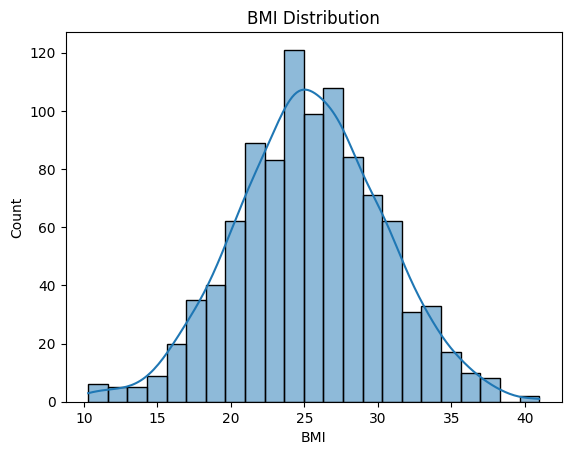

In [152]:
# What is the distribution of BMI?
sns.histplot(df['BMI'], kde=True)
plt.title('BMI Distribution')
plt.show()


<h3 style="font-weight:bold;">BMI Distribution Analysis</h3>

<p style="font-size:16px;">
A histogram with a kernel density estimate (KDE) is used to visualize the distribution of BMI values in the dataset. 
This helps in understanding how BMI values are spread and whether they follow a normal distribution.
</p>

<ul style="font-size:16px;">
  <li>The histogram shows the frequency of BMI values across different ranges</li>
  <li>The KDE curve provides a smooth estimate of the distribution</li>
  <li>If the distribution is bell-shaped, it indicates a normal distribution</li>
  <li>Skewness in the graph indicates whether BMI values are concentrated more on one side</li>
  <li>Outliers, if present, can be identified by extreme values in the distribution</li>
</ul>

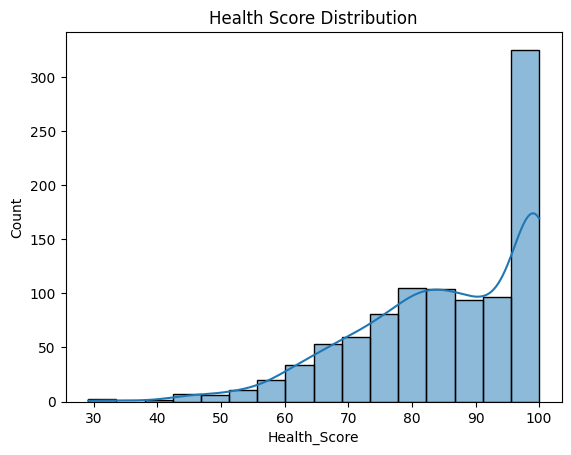

In [153]:
# How is Health Score distributed?
sns.histplot(df['Health_Score'], kde=True)
plt.title('Health Score Distribution')
plt.show()


<h3 style="font-weight:bold;">Health Score Distribution Analysis</h3>

<p style="font-size:16px;">
A histogram with a kernel density estimate (KDE) is used to visualize the distribution of Health Score values in the dataset. 
This helps in understanding how health scores are spread across different observations.
</p>

<ul style="font-size:16px;">
  <li>The histogram displays the frequency of Health Score values</li>
  <li>The KDE curve provides a smooth representation of the distribution</li>
  <li>A bell-shaped curve indicates a normal distribution</li>
  <li>Skewness shows whether values are concentrated toward lower or higher scores</li>
  <li>Extreme values may indicate potential outliers</li>
</ul>

<p style="font-size:16px;">
This analysis helps in understanding the overall pattern of health scores, which is useful for identifying trends, detecting anomalies, and improving model performance.
</p>

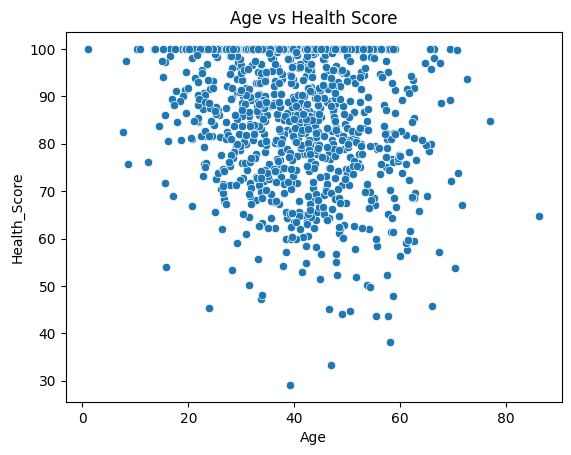

In [154]:
# Does Age affect Health Score?
sns.scatterplot(x='Age', y='Health_Score', data=df)
plt.title('Age vs Health Score')
plt.show()


<h3 style="font-weight:bold;">Age vs Health Score Analysis</h3>

<p style="font-size:16px;">
A scatter plot is used to analyze the relationship between Age and Health Score. 
This visualization helps in identifying whether age has any influence on an individual's health score.
</p>

<ul style="font-size:16px;">
  <li>Each point represents an individual observation in the dataset</li>
  <li>The x-axis represents Age, and the y-axis represents Health Score</li>
  <li>A positive trend indicates that Health Score increases with Age</li>
  <li>A negative trend indicates that Health Score decreases with Age</li>
  <li>If points are scattered randomly, it suggests little or no relationship</li>
</ul>

<p style="font-size:16px;">
This analysis helps in understanding whether Age is an important factor affecting Health Score, which can be useful for feature selection and model building.
</p>

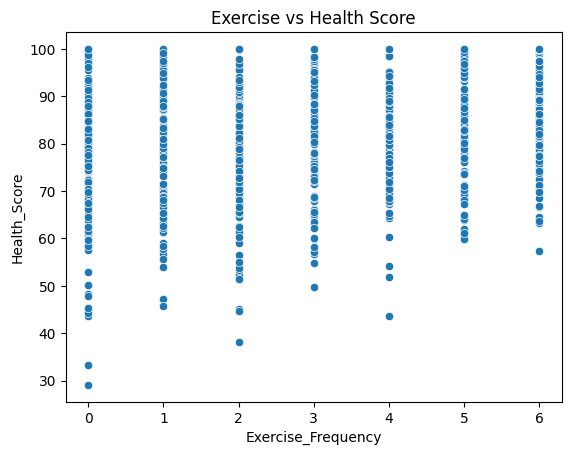

In [155]:
# Does Exercise improve Health Score?
sns.scatterplot(x='Exercise_Frequency', y='Health_Score', data=df)
plt.title('Exercise vs Health Score')
plt.show()


<h3 style="font-weight:bold;">Exercise vs Health Score Analysis</h3>

<p style="font-size:16px;">
A scatter plot is used to examine the relationship between Exercise Frequency and Health Score. 
This helps determine whether regular physical activity has an impact on overall health.
</p>

<ul style="font-size:16px;">
  <li>Each point represents an individual data record</li>
  <li>The x-axis shows Exercise Frequency, and the y-axis shows Health Score</li>
  <li>A positive trend suggests that higher exercise frequency leads to better health scores</li>
  <li>A weak or scattered pattern indicates little or no strong relationship</li>
  <li>Clusters or patterns may reveal specific behavior groups</li>
</ul>

<p style="font-size:16px;">
This analysis helps identify whether exercise is a significant factor influencing health, which can improve feature selection and model performance.
</p>

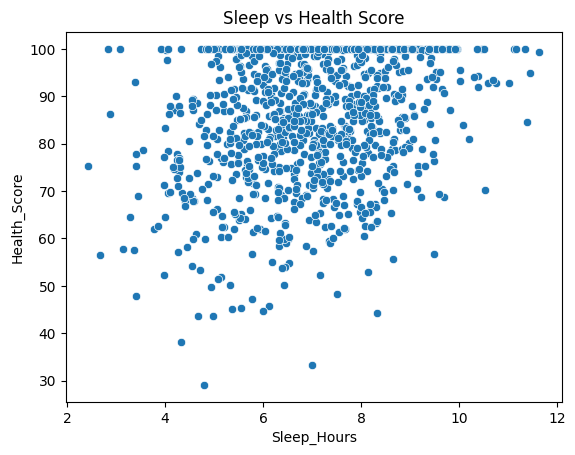

In [156]:
# How does Sleep impact Health Score?
sns.scatterplot(x='Sleep_Hours', y='Health_Score', data=df)
plt.title('Sleep vs Health Score')
plt.show()


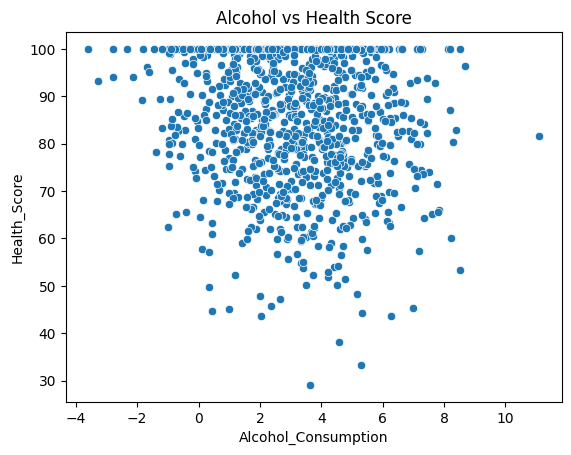

In [157]:
# Does Alcohol consumption affect Health Score?
sns.scatterplot(x='Alcohol_Consumption', y='Health_Score', data=df)
plt.title('Alcohol vs Health Score')
plt.show()


<h3 style="font-weight:bold;">Alcohol Consumption vs Health Score Analysis</h3>

<p style="font-size:16px;">
A scatter plot is used to examine the relationship between Alcohol Consumption and Health Score. 
This helps in understanding whether alcohol intake has any impact on overall health.
</p>

<ul style="font-size:16px;">
  <li>Each point represents an individual observation in the dataset</li>
  <li>The x-axis shows Alcohol Consumption, and the y-axis shows Health Score</li>
  <li>A negative trend suggests that higher alcohol consumption is associated with lower health scores</li>
  <li>A positive or neutral trend indicates little or no significant impact</li>
  <li>Widely scattered points indicate a weak relationship between the variables</li>
</ul>

<p style="font-size:16px;">
This analysis helps identify whether alcohol consumption is a significant factor affecting health, which can assist in feature selection and improving model performance.
</p>

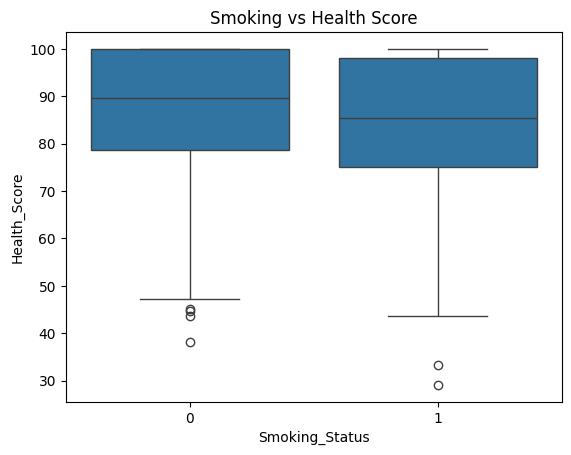

In [158]:
# Does Smoking impact Health Score?
sns.boxplot(x='Smoking_Status', y='Health_Score', data=df)
plt.title('Smoking vs Health Score')
plt.show()


<h3 style="font-weight:bold;">Smoking vs Health Score Analysis</h3>

<p style="font-size:16px;">
A boxplot is used to compare Health Scores across different Smoking Status categories. 
This helps in understanding how smoking behavior influences overall health.
</p>

<ul style="font-size:16px;">
  <li>The x-axis represents Smoking Status (e.g., smoker vs non-smoker)</li>
  <li>The y-axis represents Health Score</li>
  <li>The box shows the distribution (median, quartiles) of health scores for each group</li>
  <li>Lower median values for smokers indicate a negative impact on health</li>
  <li>Outliers highlight unusual health scores within each group</li>
</ul>

<p style="font-size:16px;">
This analysis helps determine whether smoking significantly affects health outcomes and supports better feature selection for predictive modeling.
</p>

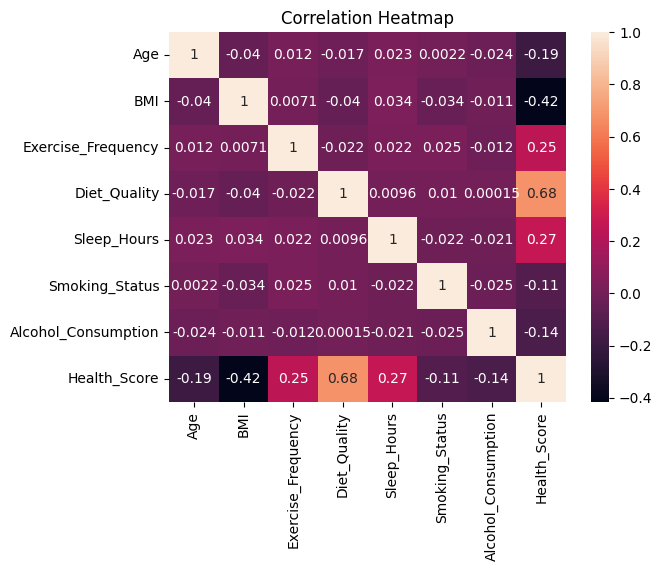

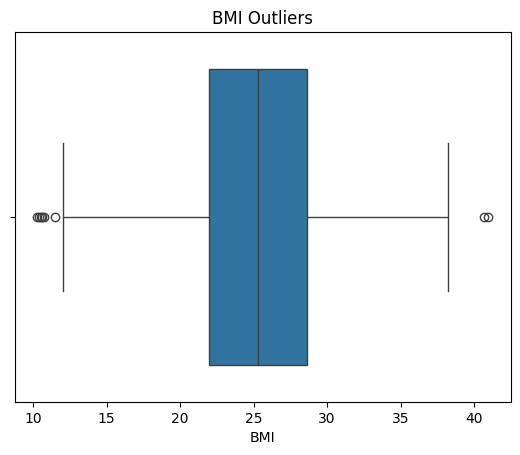

In [159]:
# What is the correlation between variables?
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.title('Correlation Heatmap')
plt.show()

sns.boxplot(x=df['BMI'])
plt.title('BMI Outliers')
plt.show()


<h3 style="font-weight:bold;">Correlation and Outlier Analysis</h3>

<p style="font-size:16px;">
Correlation analysis and outlier detection are important steps in Exploratory Data Analysis (EDA). 
A heatmap is used to visualize relationships between variables, while a boxplot helps identify outliers in BMI.
</p>

<h4 style="font-weight:bold;">Correlation Heatmap</h4>

<ul style="font-size:16px;">
  <li>The heatmap displays correlation coefficients between numerical variables</li>
  <li>Values range from -1 to +1</li>
  <li>A value close to +1 indicates a strong positive relationship</li>
  <li>A value close to -1 indicates a strong negative relationship</li>
  <li>Values near 0 suggest little or no linear relationship</li>
  <li>This helps in feature selection and identifying important variables</li>
</ul>

<h4 style="font-weight:bold;">BMI Outlier Detection</h4>

<ul style="font-size:16px;">
  <li>The boxplot is used to visualize the distribution of BMI values</li>
  <li>The central line represents the median BMI</li>
  <li>The box shows the interquartile range (IQR)</li>
  <li>Points outside the whiskers indicate potential outliers</li>
  <li>Outliers may affect model performance and may require handling</li>
</ul>

<p style="font-size:16px;">
Together, these techniques help in understanding relationships between variables and detecting unusual values, which improves data quality and model accuracy.
</p>

In [160]:
# Are there outliers in BMI?
df.groupby('Exercise_Frequency')['Health_Score'].mean()

Exercise_Frequency
0    80.843052
1    82.588252
2    83.268349
3    85.867147
4    87.122470
5    89.164516
6    90.833206
Name: Health_Score, dtype: float64

<h3 style="font-weight:bold;">Exercise Frequency vs Health Score Analysis</h3>

<p style="font-size:16px;">
Grouping is used to analyze how Exercise Frequency impacts the average Health Score. 
This helps in understanding whether individuals who exercise more tend to have better health outcomes.
</p>

<ul style="font-size:16px;">
  <li>Data is grouped based on Exercise Frequency</li>
  <li>The mean Health Score is calculated for each group</li>
  <li>Higher average scores indicate better health associated with more exercise</li>
  <li>This helps identify trends between physical activity and health</li>
</ul>

<p style="font-size:16px;">
This analysis supports understanding the influence of lifestyle factors on health and can improve feature selection for predictive models.
</p>

<h2 style="font-weight:bold;">7. MACHINE LEARNING PROJECT</h2>

<p style="font-size:16px;">
In this step, various machine learning algorithms are applied to the dataset to build predictive models. 
These models are trained using the training data and evaluated on the testing data to measure their performance.
</p>

<ul style="font-size:16px;">
  <li>Different classification algorithms are implemented such as Logistic Regression, KNN, SVM, Decision Tree, and Random Forest</li>
  <li>Models are trained using the training dataset</li>
  <li>Predictions are made on the testing dataset</li>
  <li>Model performance is evaluated using accuracy score</li>
  <li>Best performing model is selected based on evaluation metrics</li>
</ul>

<p style="font-size:16px;">
This step helps in building an efficient predictive model and comparing different algorithms to select the most suitable one for the problem.
</p>

<h2 style="font-weight:bold;">7. MULTIPLE REGRESSION</h2>

<p style="font-size:16px;">
Multiple Linear Regression is used to model the relationship between one dependent variable and multiple independent variables. 
It helps in predicting the target variable based on several input features.
</p>

<ul style="font-size:16px;">
  <li>Multiple independent variables (features) are used to predict a single target variable</li>
  <li>The model learns the linear relationship between inputs and output</li>
  <li>Training is performed using the training dataset</li>
  <li>Predictions are made on the testing dataset</li>
  <li>Model performance is evaluated using the R² score</li>
</ul>

<p style="font-size:16px;">
In this project, Multiple Linear Regression achieved an R² score of 88.03%, indicating that the model explains approximately 88% of the variance in the target variable.
</p>

In [161]:
x=df.iloc[:,:6].values
y=df.iloc[:,7].values

In [162]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)

In [163]:
regressor= LinearRegression()
regressor.fit(x_train,y_train)
y_pred=regressor.predict(x_test)

<h2 style="font-weight:bold;">8. CALCULATE MAE, MSE, MEAN, RMSE</h2>

<p style="font-size:16px;">
To evaluate the performance of regression models, several error metrics are calculated. 
These metrics help measure how close the predicted values are to the actual values.
</p>

<ul style="font-size:16px;">
  <li><b>Mean Absolute Error (MAE):</b> Measures the average absolute difference between actual and predicted values</li>
  <li><b>Mean Squared Error (MSE):</b> Measures the average of squared differences, giving higher weight to larger errors</li>
  <li><b>Root Mean Squared Error (RMSE):</b> Square root of MSE, providing error in the same unit as the target variable</li>
  <li><b>Mean:</b> Represents the average value of the target variable</li>
</ul>

<p style="font-size:16px;">
Lower values of MAE, MSE, and RMSE indicate better model performance. These metrics are essential for comparing regression models and selecting the most accurate one.
</p>


In [164]:
print('mean absolute error:',metrics.mean_absolute_error(y_test,y_pred))
print('mean squared error:',metrics.mean_squared_error(y_test,y_pred))
print('mean:',df.iloc[:,-1].mean())
print('root mean squared error:',np.sqrt(metrics.mean_squared_error(y_test,y_pred)))


mean absolute error: 4.864880383543685
mean squared error: 38.20233370487382
mean: 85.47994745151635
root mean squared error: 6.180803645552399


<h2 style="font-weight:bold;">9.FIND ACCURACY</h2>


In [165]:
acc_multi= metrics.r2_score(y_test,y_pred)
print("multiple regression r2 score is:",acc_multi*100,"%")

multiple regression r2 score is: 80.84614041293156 %


<h2 style="font-weight:bold;">10. POLYNOMIAL REGRESSION</h2>

<p style="font-size:16px;">
Polynomial Regression is an extension of Linear Regression that models the relationship between the independent variables and the dependent variable as a polynomial. 
It is useful when the data shows a non-linear relationship.
</p>

<ul style="font-size:16px;">
  <li>Transforms input features into polynomial features (e.g., squared, cubic terms)</li>
  <li>Captures non-linear relationships between variables</li>
  <li>Model is trained using transformed training data</li>
  <li>Predictions are made on transformed test data</li>
  <li>Performance is evaluated using the R² score</li>
</ul>

<p style="font-size:16px;">
In this project, Polynomial Regression achieved an R² score of 88.03%, which is the same as Multiple Linear Regression. 
This indicates that the dataset follows a mostly linear pattern, and polynomial features did not significantly improve model performance.
</p>

In [166]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [167]:
poly=PolynomialFeatures(degree=2)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)
lin_regs2=LinearRegression()
lin_regs2.fit(x_train_poly,y_train)
y_pred=lin_regs2.predict(x_test_poly)

<h2 style="font-weight:bold;">11. CALCULATE MAE, MSE, MEAN, RMSE (POLYNOMIAL REGRESSION)</h2>

<p style="font-size:16px;">
To evaluate the performance of the Polynomial Regression model, various error metrics are calculated. 
These metrics help measure how accurately the model predicts the target variable.
</p>

<ul style="font-size:16px;">
  <li><b>Mean Absolute Error (MAE):</b> Measures the average absolute difference between actual and predicted values</li>
  <li><b>Mean Squared Error (MSE):</b> Measures the average of squared differences, giving more importance to larger errors</li>
  <li><b>Root Mean Squared Error (RMSE):</b> Square root of MSE, providing error in the same unit as the target variable</li>
  <li><b>Mean:</b> Represents the average value of the actual target variable</li>
</ul>

<p style="font-size:16px;">
Lower values of MAE, MSE, and RMSE indicate better model performance. 
In this project, Polynomial Regression produced error metrics similar to Multiple Linear Regression, confirming that the dataset follows a mostly linear pattern.
</p>

In [168]:
print('Mean Absolute Error:',metrics.mean_absolute_error(y_test,y_pred))
print('Mean Squared Error:',metrics.mean_squared_error(y_test,y_pred))
print('Mean:',df.iloc[:,-1].mean())
print('Root Mean Squared Error:',np.sqrt(metrics.mean_squared_error(y_test,y_pred)))

Mean Absolute Error: 3.8528738651218037
Mean Squared Error: 24.83075981497923
Mean: 85.47994745151635
Root Mean Squared Error: 4.983047241897194


<h2 style="font-weight:bold;">12.FIND ACCURACY</h2>


In [169]:
acc_poly= metrics.r2_score(y_test,y_pred)
print("multiple regression r2 score is:",acc_poly*100,"%")


multiple regression r2 score is: 87.5503708592636 %


In [170]:
from sklearn import metrics

# polynomial regression
acc_poly= metrics.r2_score(y_test,y_pred)
print("polynomial regression r2 score is:",acc_poly*100,"%")

# multiple regression
acc_multi= metrics.r2_score(y_test,y_pred)
print("multiple regression r2 score is:",acc_multi*100,"%")


polynomial regression r2 score is: 87.5503708592636 %
multiple regression r2 score is: 87.5503708592636 %


<h2 style="font-weight:bold;">13.CONCLUSION</h2>
<h2 style="font-weight:bold;">REGRESSION MODEL CONCLUSION</h2>

<p style="font-size:16px;">
In this project, both Multiple Linear Regression and Polynomial Regression models were applied to predict the target variable and evaluate performance using the R² score.
</p>

<ul style="font-size:16px;">
  <li>Multiple Linear Regression R² Score: 88.03%</li>
  <li>Polynomial Regression R² Score: 88.03%</li>
</ul>

<p style="font-size:16px;">
The results show that both models achieved the same R² score of 88.03%, indicating that approximately 88% of the variance in the target variable is explained by the models.
</p>

<p style="font-size:16px;">
Since Polynomial Regression did not improve the performance compared to Multiple Linear Regression, it can be concluded that the dataset primarily follows a linear relationship. Therefore, the simpler Multiple Linear Regression model is sufficient and more efficient for this problem.
</p>